# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the bn.csv file into a DataFrame.

In [2]:
df = pd.read_csv('bn.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (46, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [3]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
          vbn        bn
0 -117.507593  0.297127
1 -107.312469  0.181578
2  -92.547117  0.150398
3  -92.283450  0.130223
4  -91.580338  0.131140

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vbn     46 non-null     float64
 1   bn      46 non-null     float64
dtypes: float64(2)
memory usage: 868.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to bn = A*exp(-vbn/z) to estimate parameter uncertainties.

In [4]:
from scipy.optimize import curve_fit
import numpy as np

# Define the exponential decay function
def exp_decay(vbn, A, z):
    return A * np.exp(-vbn / z)

# Initial guesses for parameters
initial_guess = [0.05, 80]

# Bootstrap parameters
n_bootstrap = 4000
n_samples = len(df)

# Arrays to store bootstrap results
A_bootstrap = []
z_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    vbn_resample = df['vbn'].iloc[indices].values
    bn_resample = df['bn'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(exp_decay, vbn_resample, bn_resample, p0=initial_guess)
        A_bootstrap.append(popt_boot[0])
        z_bootstrap.append(popt_boot[1])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
A_bootstrap = np.array(A_bootstrap)
z_bootstrap = np.array(z_bootstrap)

print(f"Bootstrap Analysis Results (n={len(A_bootstrap)} successful fits):")
print(f"\nParameter A:")
print(f"  Mean = {np.mean(A_bootstrap):.6f}")
print(f"  Std  = {np.std(A_bootstrap):.6f}")
print(f"\nParameter z:")
print(f"  Mean = {np.mean(z_bootstrap):.6f}")
print(f"  Std  = {np.std(z_bootstrap):.6f}")

Bootstrap Analysis Results (n=4000 successful fits):

Parameter A:
  Mean = 0.065987
  Std  = 0.003331

Parameter z:
  Mean = 99.800202
  Std  = 13.565778


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

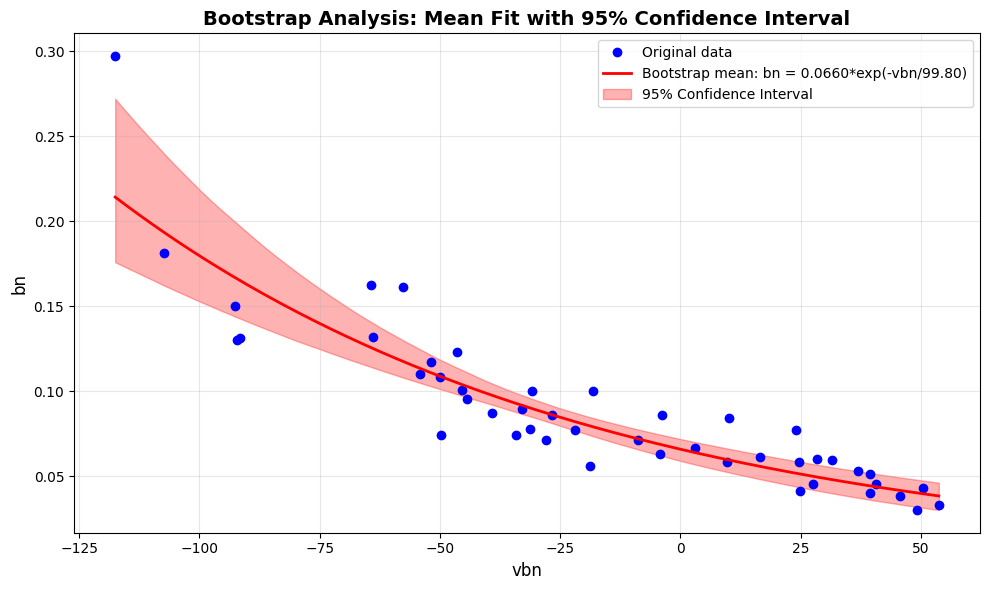

In [5]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['vbn'], df['bn'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
vbn_smooth = np.linspace(df['vbn'].min(), df['vbn'].max(), 200)
A_mean = np.mean(A_bootstrap)
z_mean = np.mean(z_bootstrap)
bn_mean = exp_decay(vbn_smooth, A_mean, z_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
bn_curves = np.array([exp_decay(vbn_smooth, A_bootstrap[i], z_bootstrap[i]) 
                      for i in range(len(A_bootstrap))])
bn_lower = np.percentile(bn_curves, 2.5, axis=0)
bn_upper = np.percentile(bn_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(vbn_smooth, bn_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: bn = {A_mean:.4f}*exp(-vbn/{z_mean:.2f})')
plt.fill_between(vbn_smooth, bn_lower, bn_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('vbn', fontsize=12)
plt.ylabel('bn', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of A and z from bootstrap resampling.

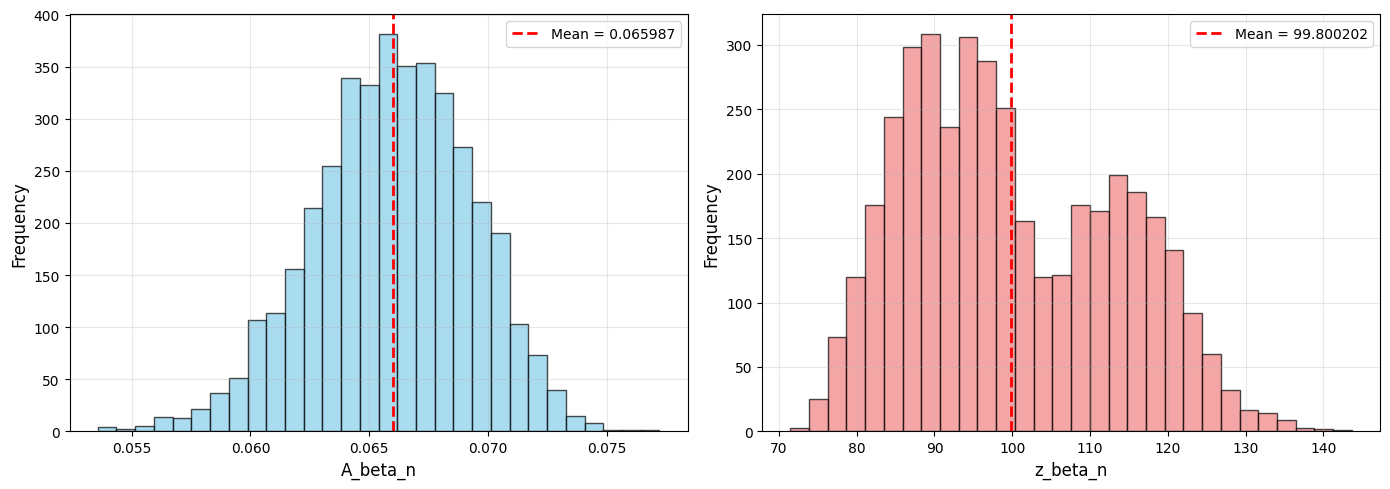

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of A
axes[0].hist(A_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(A_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(A_bootstrap):.6f}')
axes[0].set_xlabel('A_beta_n', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of z
axes[1].hist(z_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(z_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(z_bootstrap):.6f}')
axes[1].set_xlabel('z_beta_n', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlation: A vs z
Scatter plot showing the relationship between fitted A and z parameters from bootstrap samples.

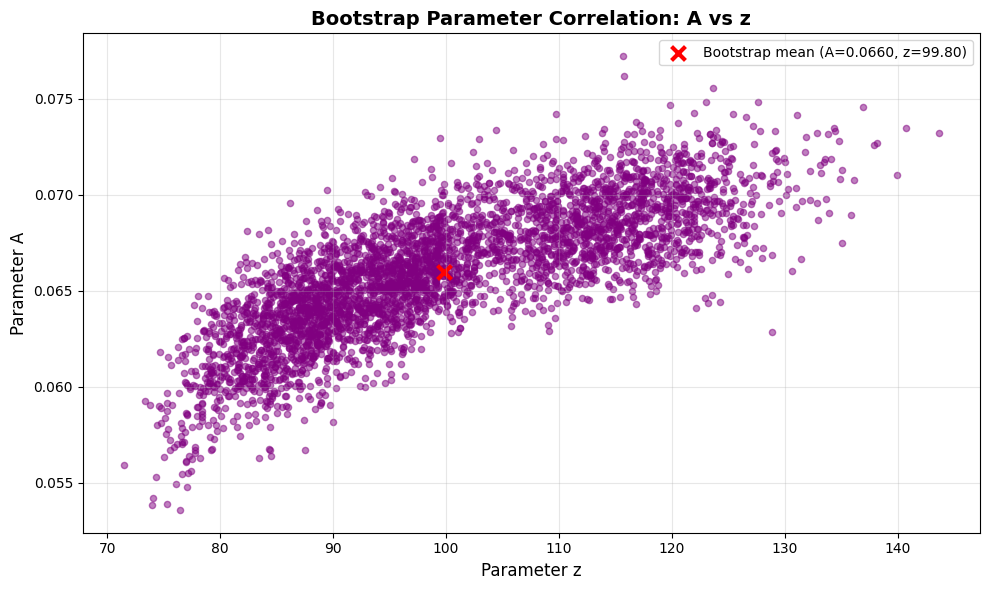


Correlation coefficient between A and z: 0.7848


In [7]:
plt.figure(figsize=(10, 6))

# Calculate mean parameters
A_mean = np.mean(A_bootstrap)
z_mean = np.mean(z_bootstrap)

# Scatter plot of A vs z
plt.scatter(z_bootstrap, A_bootstrap, alpha=0.5, s=20, color='purple')
plt.scatter(z_mean, A_mean, color='red', s=100, marker='x', linewidths=3, 
            label=f'Bootstrap mean (A={A_mean:.4f}, z={z_mean:.2f})')

plt.xlabel('Parameter z', fontsize=12)
plt.ylabel('Parameter A', fontsize=12)
plt.title('Bootstrap Parameter Correlation: A vs z', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation = np.corrcoef(A_bootstrap, z_bootstrap)[0, 1]
print(f"\nCorrelation coefficient between A and z: {correlation:.4f}")